# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [ ]:
# !pip install peft==0.13.2, transformers==4.41.1

In [ ]:
# !pip install wordcloud

In [ ]:
# !pip install imblearn

In [ ]:
# !pip install lightgbm

In [ ]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 1.2 Seeds \& Device

In [ ]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cuda


## 1.3 Configuration

In [ ]:
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label"
RAW_DATA_FILE = "data/drugscom_plus_ai_labels.csv"
OUTPUT_DIR = "outputs_text_only"

TEXT_COLUMN = "review"
LABEL_COLUMN = "aspect_3class"
LABEL_COLUMN_ENCODED = "sentiment_Encoded"

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": None},
    "biobert": {"model": OUTPUT_PATH / "best_biobert_model.pth", "params": None},
}

RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

print("--- Configuration Loaded ---")
print(f"  Project : {DRIVE_PROJECT_PATH}")
print(f"  Source  : {RAW_DATA_PATH}")
print(f"  Output  : {OUTPUT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  FP16    : {USE_FP16}")

--- Configuration Loaded ---
  Project : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label
  Source  : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/data/drugscom_plus_ai_labels.csv
  Output  : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_only
  Classes : ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
  FP16    : True


## 1.4 Load the data

In [ ]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")

df_raw.head()

Loaded 102061 rows.


,drugName,ingredient_norm,ingredient_set_key,n_ingredients,condition,condition_norm,review,text_norm,rating,date,...,ai_p_very_positive,ai_efficacy,ai_safety,ai_burden,ai_cost,ai_model,ai_seed,ai_temp,ai_ts_utc,ai_raw_json
uniqueID,,,,,,,,,,,,,,,,,,,,,
124923,Allopurinol,allopurinol,allopurinol,1,Gout,gout,"""\r\n300 mg and colcris to reduce anything the...",""" 300 mg and colcris to reduce anything the mi...",3,18-Feb-17,...,0.0,POSITIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612186+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
127676,Phentermine,phentermine,phentermine,1,Weight Loss,weight loss,"""\r\nA previous poster Ryan Smith said &quot;I...",""" a previous poster ryan smith said ""i've seen...",10,16-Apr-17,...,0.5,POSITIVE,NEUTRAL,POSITIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612311+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
81819,Liraglutide,liraglutide,liraglutide,1,Obesity,obesity,""" began with the minimum 0.6 mg dose of Saxend...",""" began with the minimum 0.6 mg dose of saxend...",10,18-Mar-17,...,0.1,POSITIVE,NEGATIVE,NEUTRAL,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612391+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
170223,Quetiapine,quetiapine,quetiapine,1,Bipolar Disorde,bipolar disorde,""" Caused depression and negative, self defeati...",""" caused depression and negative, self defeati...",1,25-Aug-16,...,0.0,NEGATIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612469+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
48454,Ethinyl estradiol / levonorgestrel,ethinyl estradiol / levonorgestrel,ethinyl estradiol / levonorgestrel,2,Birth Control,birth control,""" Ever since I started taking this birth contr...",""" ever since i started taking this birth contr...",1,30-Oct-17,...,0.0,NEGATIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612538+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."


In [ ]:
# -- R1 label-granularity baseline: primary 5-class collapsed to 3-class ----
ASPECT_COLS = ["ai_efficacy", "ai_safety", "ai_burden", "ai_cost"]

WEIGHT_SCHEME_NAME = "integer_2112_primary_3class_collapsed"
WEIGHT_SCHEME_NOTE = "Reviewer baseline: keep the primary R0 2:1:1:2 aspect weights and submitted thresholds, then collapse the 5-class fused label to 3 classes."
THRESHOLD_SCHEME_NAME = "primary_2112_submitted"
THRESHOLD_SCHEME_NOTE = "Submitted thresholds: score >= 5 very positive, >= 2 positive, >= -1 neutral, >= -4 negative, else very negative."
LABEL_GRANULARITY_NAME = "collapsed_5class_to_3class"

# Keep the submitted integer 2:1:1:2 weighting and primary thresholds.
ASPECT_WEIGHTS_RAW = {
    "ai_efficacy": 2.0,
    "ai_safety": 1.0,
    "ai_burden": 1.0,
    "ai_cost": 2.0
}
POLARITY_MAP = {"POSITIVE": 1, "NEUTRAL": 0, "NEGATIVE": -1}
TARGET_SCORE_RANGE = 6.0
WEIGHT_SCALE = TARGET_SCORE_RANGE / sum(abs(v) for v in ASPECT_WEIGHTS_RAW.values())
ASPECT_WEIGHTS = {k: float(v) * WEIGHT_SCALE for k, v in ASPECT_WEIGHTS_RAW.items()}

print(f"=== R1 label granularity baseline: {LABEL_GRANULARITY_NAME} ===")
print(WEIGHT_SCHEME_NOTE)
print(THRESHOLD_SCHEME_NOTE)
print("Raw weights:", ASPECT_WEIGHTS_RAW)
print("Scaled weights (sum abs = 6):", {k: round(v, 4) for k, v in ASPECT_WEIGHTS.items()})

# -- 1. Per-record counts (unweighted, for reference) -----
for val in ["POSITIVE", "NEGATIVE", "NEUTRAL"]:
    df_raw[f"n_{val.lower()}"] = (
        df_raw[ASPECT_COLS].apply(lambda row: (row == val).sum(), axis=1)
    )

# -- 2. Weighted score normalized to R0 score range [-6, +6] --
df_raw["aspect_wscore"] = sum(
    ASPECT_WEIGHTS[asp] * df_raw[asp].map(POLARITY_MAP).fillna(0).astype(float)
    for asp in ASPECT_COLS
)

df_raw["aspect_weight_scheme"] = WEIGHT_SCHEME_NAME
df_raw["aspect_threshold_scheme"] = THRESHOLD_SCHEME_NAME
df_raw["aspect_label_granularity"] = LABEL_GRANULARITY_NAME

print("=== Weighted aspect score distribution ===")
print(df_raw["aspect_wscore"].round(4).value_counts().sort_index())

print("=== Cross-tab: aspect counts ===")
print(f"Mean #POSITIVE per record: {df_raw['n_positive'].mean():.2f}")
print(f"Mean #NEGATIVE per record: {df_raw['n_negative'].mean():.2f}")
print(f"Mean #NEUTRAL  per record: {df_raw['n_neutral'].mean():.2f}")

# -- 3. Derive primary hard 5-class label from weighted score -----
def wscore_to_5class(score):
    if score >= 5:
        return "VERY_POSITIVE"
    elif score >= 2:
        return "POSITIVE"
    elif score >= -1:
        return "NEUTRAL"
    elif score >= -4:
        return "NEGATIVE"
    else:
        return "VERY_NEGATIVE"

COLLAPSE_5_TO_3 = {
    "VERY_NEGATIVE": "NEGATIVE",
    "NEGATIVE": "NEGATIVE",
    "NEUTRAL": "NEUTRAL",
    "POSITIVE": "POSITIVE",
    "VERY_POSITIVE": "POSITIVE",
}

df_raw["aspect_5class"] = df_raw["aspect_wscore"].apply(wscore_to_5class)
df_raw["aspect_3class"] = df_raw["aspect_5class"].map(COLLAPSE_5_TO_3)

print("=== Primary aspect-derived 5-class distribution ===")
print(df_raw["aspect_5class"].value_counts())
print("=== Collapsed aspect-derived 3-class distribution ===")
print(df_raw["aspect_3class"].value_counts())


=== R1 label granularity baseline: collapsed_5class_to_3class ===
Reviewer baseline: keep the primary R0 2:1:1:2 aspect weights and submitted thresholds, then collapse the 5-class fused label to 3 classes.
Submitted thresholds: score >= 5 very positive, >= 2 positive, >= -1 neutral, >= -4 negative, else very negative.
Raw weights: {'ai_efficacy': 2.0, 'ai_safety': 1.0, 'ai_burden': 1.0, 'ai_cost': 2.0}
Scaled weights (sum abs = 6): {'ai_efficacy': 2.0, 'ai_safety': 1.0, 'ai_burden': 1.0, 'ai_cost': 2.0}
=== Weighted aspect score distribution ===
aspect_wscore
-6.0     1272
-5.0      547
-4.0    18286
-3.0     6209
-2.0     4507
-1.0     3551
 0.0     8450
 1.0    11396
 2.0    19364
 3.0    17120
 4.0     9354
 5.0      907
 6.0     1098
Name: count, dtype: int64
=== Cross-tab: aspect counts ===
Mean #POSITIVE per record: 1.07
Mean #NEGATIVE per record: 1.07
Mean #NEUTRAL  per record: 1.85
=== Primary aspect-derived 5-class distribution ===
aspect_5class
POSITIVE         45838
NEGATIVE

# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [ ]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

,drugName,ingredient_norm,ingredient_set_key,n_ingredients,condition,condition_norm,review,text_norm,rating,date,...,ai_raw_json,n_positive,n_negative,n_neutral,aspect_wscore,aspect_weight_scheme,aspect_threshold_scheme,aspect_label_granularity,aspect_5class,aspect_3class
0,Benzoyl peroxide / clindamycin,benzoyl peroxide / clindamycin,benzoyl peroxide / clindamycin,2,Acne,acne,"""I was never one to have severe acne, just a f...","""i was never one to have severe acne, just a f...",10,20-May-15,...,"[\n {\n ""index"": 0,\n ""ai_rat...",3,0,1,4.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,POSITIVE,POSITIVE
1,Nexplanon,etonogestrel,etonogestrel,1,Birth Control,birth control,"""I&#039;ve had the Nexplanon since May 2015.I ...","""i've had the nexplanon since may 2015.i got i...",6,12-Oct-16,...,"[\n {\n ""index"": 0,\n ""ai_rat...",1,1,2,1.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,NEUTRAL,NEUTRAL
2,Buspirone,buspirone,buspirone,1,Anxiety,anxiety,"""I have been taking Buspar for just over 8 mon...","""i have been taking buspar for just over 8 mon...",10,1-Sep-08,...,"[\n {\n ""index"": 0,\n ""ai_rat...",2,0,2,3.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,POSITIVE,POSITIVE
3,Buspirone,buspirone,buspirone,1,Anxiety,anxiety,"""I&#039;ve been on this for two weeks. I went ...","""i've been on this for two weeks. i went to my...",8,22-Aug-16,...,"[\n {\n ""index"": 0,\n ""ai_rat...",2,0,2,3.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,POSITIVE,POSITIVE
4,Liraglutide,liraglutide,liraglutide,1,"Diabetes, Type 2","diabetes, type 2","""I Love this medication!!! My blood sugar stay...","""i love this medication!!! my blood sugar stay...",9,27-Oct-15,...,"[\n {\n ""index"": 0,\n ""ai_rat...",1,2,1,-1.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,NEUTRAL,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102056,Plan B One-Step,levonorgestrel,levonorgestrel,1,Emergency Contraception,emergency contraception,"""My lover and I had unprotected sex on 12/26 w...","""my lover and i had unprotected sex on 12/26 w...",9,11-Jan-16,...,"[\n {\n ""index"": 0,\n ""ai_rat...",1,0,3,2.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,POSITIVE,POSITIVE
102057,Esomeprazole / naproxen,esomeprazole / naproxen,esomeprazole / naproxen,2,Osteoarthritis,osteoarthritis,"""Great for relief of back pain BUT severe side...","""great for relief of back pain but severe side...",3,24-Aug-16,...,"[\n {\n ""index"": 0,\n ""ai_rat...",0,3,1,-4.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,NEGATIVE,NEGATIVE
102058,Dupilumab,dupilumab,dupilumab,1,Eczema,eczema,"""I am a 30 year old female who has had eczema ...","""i am a 30 year old female who has had eczema ...",8,28-Aug-17,...,"[\n {\n ""index"": 0,\n ""ai_rat...",1,0,3,2.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,POSITIVE,POSITIVE
102059,Letrozole,letrozole,letrozole,1,Breast Cance,breast cance,"""Used for 4.6years. Experienced many common s...","""used for 4.6years. experienced many common si...",10,11-Jun-16,...,"[\n {\n ""index"": 0,\n ""ai_rat...",0,0,4,0.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,NEUTRAL,NEUTRAL


## 2.2 Master Data Preparation

In [ ]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [ ]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")

Label mapping: {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df_clean: 102061 rows


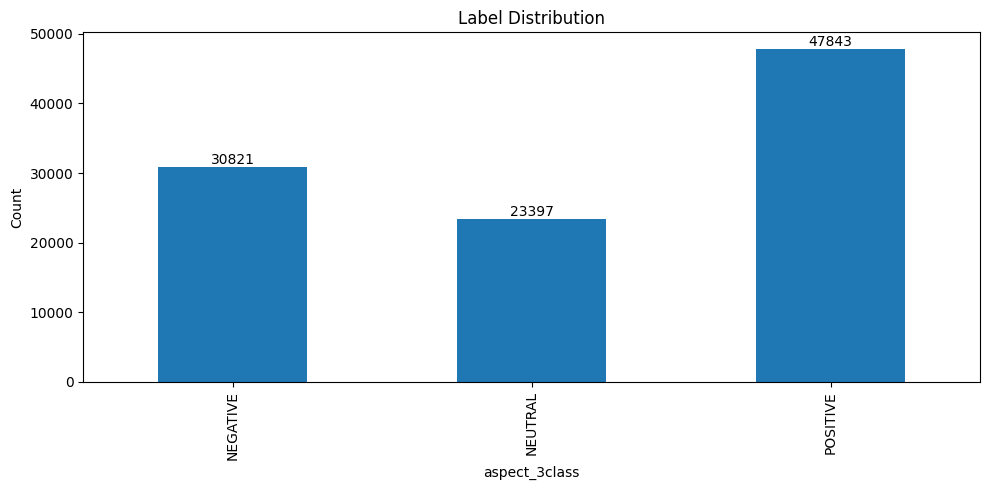

In [ ]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [ ]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

# 80/20 → trainval / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# 75/25 of trainval → train / val (≈60/20/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[LABEL_COLUMN_ENCODED], groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby(TEXT_COLUMN)["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))

# Save master split
split_path = OUTPUT_PATH / "DrugReview_master_split.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")

Split counts:
split
train    61309
test     20383
val      20369
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.600709
test     0.199714
val      0.199577
Name: proportion, dtype: float64
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_only/DrugReview_master_split.csv


## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [ ]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [ ]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [ ]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [ ]:

def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [ ]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers all use review text ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from review text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len (not max-in-split)
        padded = seq + [0] * (max_len - len(seq))
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)


train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

DL splits: train=61309, val=20369, test=20383
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([61309, 200]), val=torch.Size([20369, 200]), test=torch.Size([20383, 200])


In [ ]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True, **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [ ]:
def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ALBERT tokens: train=torch.Size([61309, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])
else:
    print("Loading ALBERT from disk...")
    best_albert = AlbertForSequenceClassification.from_pretrained(
        "albert-base-v2", num_labels=NUM_CLASSES,
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.bias       | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.bias       | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=0.8075 | Val F1=0.7581
  Epoch 2/9 | Loss=0.5393 | Val F1=0.7493
  Epoch 3/9 | Loss=0.4403 | Val F1=0.7963
  Epoch 4/9 | Loss=0.3395 | Val F1=0.7953
  Epoch 5/9 | Loss=0.2276 | Val F1=0.7917
  Epoch 6/9 | Loss=0.1239 | Val F1=0.7913
  Early stopping at epoch 6.


ALBERT Random Search: 100%|██████████| 10/10 [1:22:05<00:00, 492.51s/it]

ALBERT tuning: 4925.1s | Best F1=0.8006
Best params: {'lr': 1.6488764559753468e-05, 'epochs': 4, 'dropout': 0.09460120283387222}


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 160/160 [00:11<00:00, 13.44it/s]



Evaluation: ALBERT
              precision    recall  f1-score   support

    NEGATIVE     0.8522    0.8558    0.8540      6124
     NEUTRAL     0.5649    0.6338    0.5974      4749
    POSITIVE     0.8769    0.8211    0.8481      9510

    accuracy                         0.7879     20383
   macro avg     0.7647    0.7703    0.7665     20383
weighted avg     0.7968    0.7879    0.7915     20383

Weighted F1: 0.7914  95% CI [0.7859, 0.7969]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_only/ALBERT_confusion_matrix.png


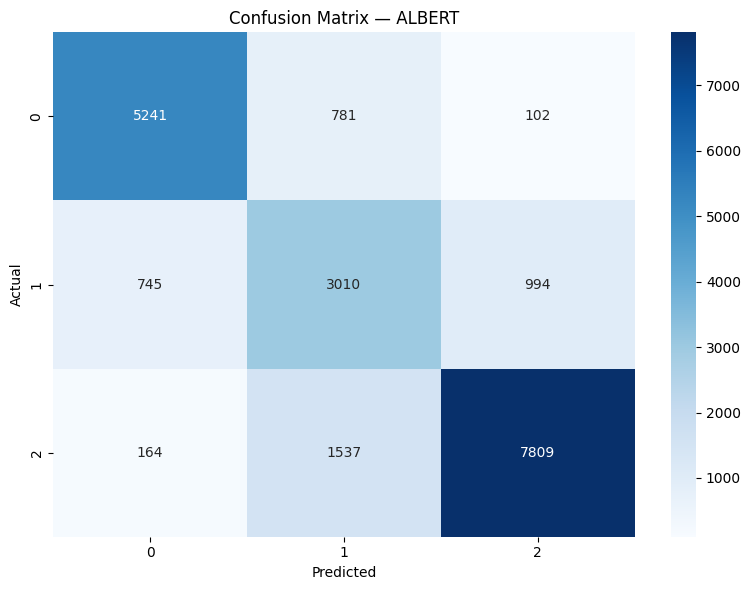

Macro AUC: 0.9208  95% CI [0.9178, 0.9238]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_only/ALBERT_roc_curve.png


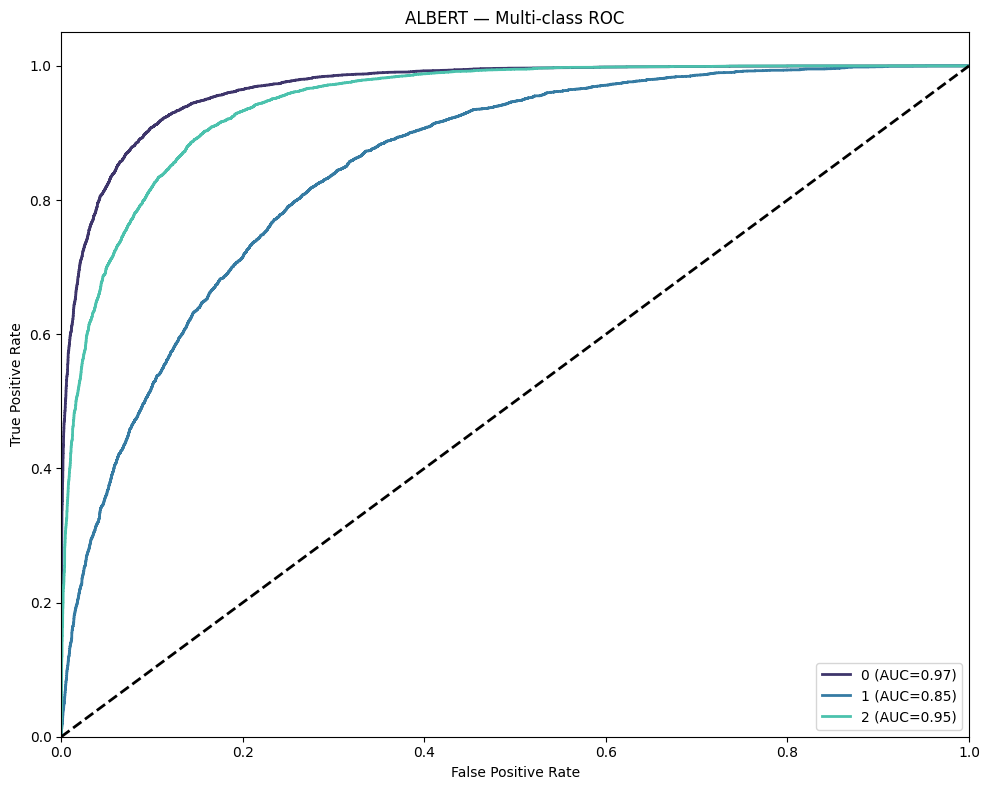

In [ ]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

### 4.4.3 BioBERT Modeling

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for BioBERT...")
biobert_name = "dmis-lab/biobert-base-cased-v1.2"
biobert_tokenizer = AutoTokenizer.from_pretrained(biobert_name)

train_ids_bio, train_masks_bio = batch_tokenize(train_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_bio, val_masks_bio     = batch_tokenize(val_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_bio, test_masks_bio   = batch_tokenize(test_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
print(f"BioBERT tokens: train={train_ids_bio.shape}")

train_loader_biobert = DataLoader(
    TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_biobert = DataLoader(
    TransformerDataset(val_ids_bio, val_masks_bio, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_biobert = DataLoader(
    TransformerDataset(test_ids_bio, test_masks_bio, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for BioBERT...


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BioBERT tokens: train=torch.Size([61309, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning BioBERT...")
    start = time.time()

    biobert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*biobert_param_space["lr"])),
            "epochs": int(np.random.randint(*biobert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*biobert_param_space["dropout"])),
        }

        model = AutoModelForSequenceClassification.from_pretrained(
            biobert_name, num_labels=NUM_CLASSES,
        )
        model.config.hidden_dropout_prob = hp["dropout"]
        model.config.attention_probs_dropout_prob = hp["dropout"]

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    torch.save(best_biobert.state_dict(), MODEL_PATHS["biobert"]["model"])
else:
    print("Loading BioBERT from disk...")
    best_biobert = AutoModelForSequenceClassification.from_pretrained(
        biobert_name, num_labels=NUM_CLASSES,
    )
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))
    print(f"Loaded BioBERT from {MODEL_PATHS['biobert']['model']}")


Tuning BioBERT...


BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

  Epoch 1/9 | Loss=0.8107 | Val F1=0.7639
  Epoch 2/9 | Loss=0.5452 | Val F1=0.7830
  Epoch 3/9 | Loss=0.4134 | Val F1=0.7777
  Epoch 4/9 | Loss=0.3014 | Val F1=0.7679
  Epoch 5/9 | Loss=0.2118 | Val F1=0.7746
  Early stopping at epoch 5.


BioBERT Random Search: 100%|██████████| 10/10 [1:02:01<00:00, 372.10s/it]


BioBERT tuning: 3721.0s | Best F1=0.7851
Best params: {'lr': 2.0794564875777272e-05, 'epochs': 6, 'dropout': 0.15520777454277573}


#### Step 3: Model Evaluation

Eval BioBERT: 100%|██████████| 160/160 [00:04<00:00, 33.93it/s]



Evaluation: BioBERT
              precision    recall  f1-score   support

    NEGATIVE     0.8569    0.8165    0.8362      6124
     NEUTRAL     0.5392    0.6288    0.5805      4749
    POSITIVE     0.8624    0.8170    0.8391      9510

    accuracy                         0.7730     20383
   macro avg     0.7528    0.7541    0.7519     20383
weighted avg     0.7854    0.7730    0.7780     20383

Weighted F1: 0.7780  95% CI [0.7723, 0.7835]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_only/BioBERT_confusion_matrix.png


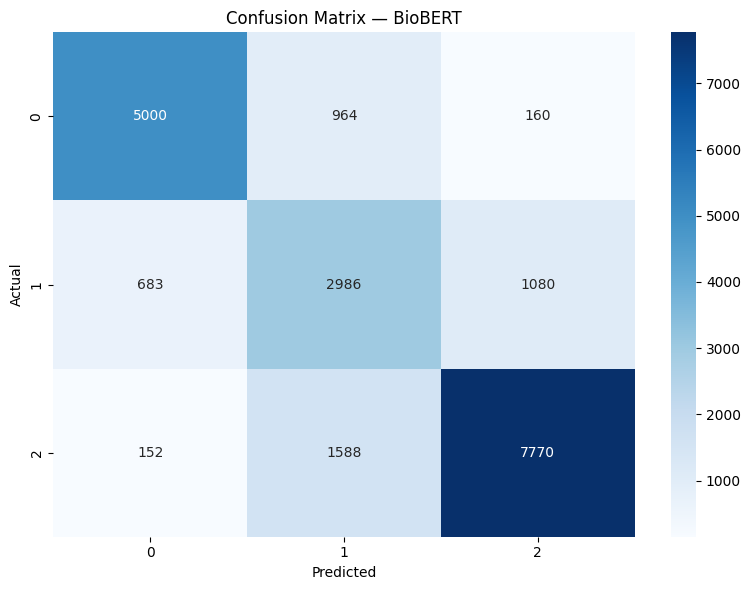

Macro AUC: 0.9116  95% CI [0.9083, 0.9147]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_only/BioBERT_roc_curve.png


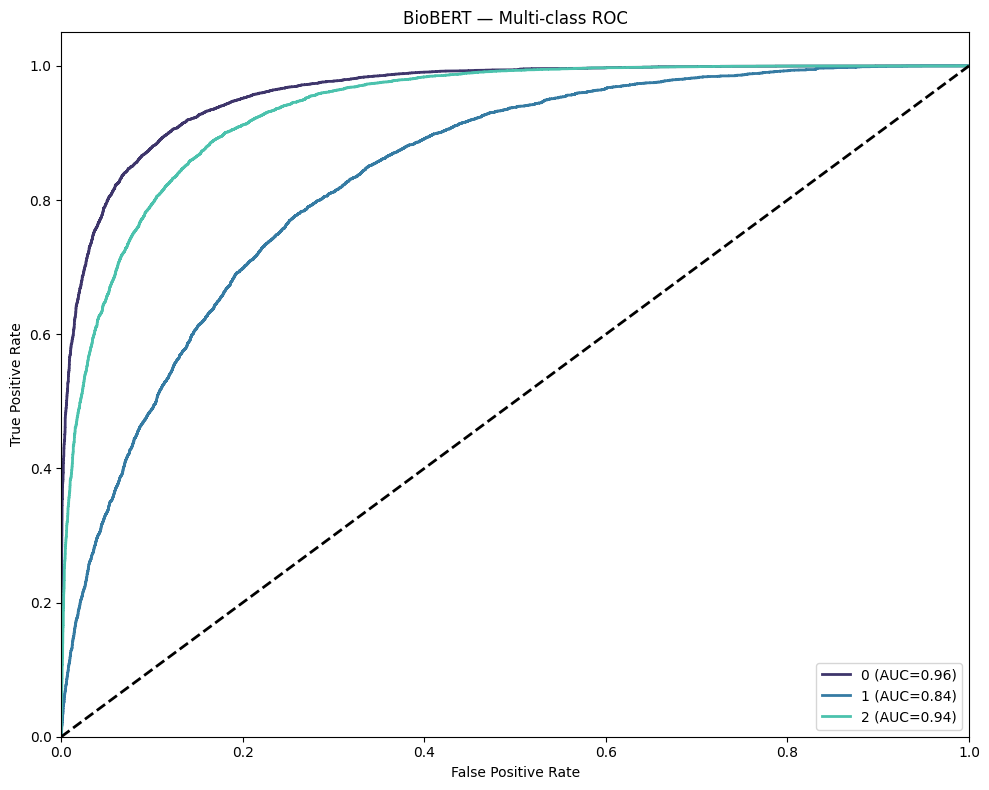

In [ ]:
biobert_preds, biobert_probs, y_true_biobert = evaluate_pytorch(
    best_biobert, test_loader_biobert, label_encoder, "BioBERT", use_attention_mask=True
)